# 05 - Algoritmo Genético para Otimização de Hiperparâmetros

## Contexto baseline

Carrega os artefatos produzidos no (notebook 03)[../'Fase 1'/03_modeling.ipynb] (dados no cenário B, parâmetros do melhor `HistGB` encontrado por `RandomizedSearch`) e registra as métricas de referência que o algoritmo genético precisa superar.

Escolhas metodológicas mantidas da Fase 1:
- Cenário B (ordinal + contínuo, 29 features) - mesma interpretabilidade, mesmo ROC-AUC que C
- `sample_weight=balanced` no treino  - tratamento do desbalanceamento 90/10
- Critério clínico: recall >= 0.80 como restrição hard; **F2 como objetivo** (beta=2, consistente com Fase 1)
- `RANDOM_STATE=42`, `CV_SPLITS=3`

In [1]:
import gc
import json
import math
import os
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from joblib import Parallel, delayed

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from pipeline import apply_scenario

In [2]:
SRC_DIR  = Path("../src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

warnings.filterwarnings("ignore")

RANDOM_STATE = 42  # semente para reprodutibilidade
CV_SPLITS = 3      # número de folds na validação cruzada
MIN_RECALL_THRESHOLD  = 0.80    # piso clínico: o modelo precisa capturar 80% dos prematuros
OPERATIONAL_THRESHOLD = 0.40    # threshold de decisão escolhido na Fase 1
SCENARIO              = "B"     # cenário de features: ordinal + contínuo (29 features)

DATA_DIR = Path("../data")
METRICS_DIR = Path("../results/metrics")
ARTIFACTS_DIR = Path("../results/artifacts")
FIGURES_DIR   = Path("../results/figures")


In [3]:
def get_n_jobs(capacity: float = 0.80) -> int:
    """Retorna floor(n_cpus * capacity), mínimo 1."""
    return max(1, math.floor(os.cpu_count() * capacity))

N_JOBS = get_n_jobs(0.80)
print(f"CPUs disponíveis : {os.cpu_count()}")
print(f"n_jobs (80%)     : {N_JOBS}")

CPUs disponíveis : 12
n_jobs (80%)     : 9


### Carga dos dados (cenário B)

In [4]:
def load_scenario_data(scenario: str) -> tuple:

    X_train_full = pd.read_parquet(DATA_DIR / "X_train.parquet")
    X_test_full = pd.read_parquet(DATA_DIR / "X_test.parquet")
    y_train = pd.read_parquet(DATA_DIR / "y_train.parquet").iloc[:,0]
    y_test = pd.read_parquet(DATA_DIR / "y_test.parquet").iloc[:,0]
    
    X_train = apply_scenario(X_train_full, "B") # remove as colunas que não pertencem ao cenário B,
    X_test = apply_scenario(X_test_full, "B")

    return(
        X_train,
        X_test,
        y_train,
        y_test
    )

In [5]:
X_train, X_test, y_train, y_test = load_scenario_data(SCENARIO)
print("X_train cenário B:", X_train.shape)
print("X_test cenário B:", X_test.shape)
print("Distribuição y_train:", y_train.value_counts(normalize=True).round(3).to_dict())
# Esperado: ~0.90 não-prematuro, ~0.10 prematur

X_train cenário B: (562520, 26)
X_test cenário B: (140630, 26)
Distribuição y_train: {0: 0.889, 1: 0.111}


### Carrega parâmetros e métricas do baseline (JSON Fase 1)

O arquivo `best_model_operational_metrics.json` foi salvo pelo notebook 03.
Ele contém os melhores hiperparâmetros encontrados pelo RandomizedSearch.
Vamos lê-los para não precisar redigitar e evitar erros.

**Por que recomputar as métricas em vez de usar as do JSON?**
O modelo salvo no `.pkl` está *calibrado* (passado por `CalibratedClassifierCV`).
O algoritmo genético vai treinar modelos *sem* calibração para ser mais rápido.
Para a comparação ser justa, o baseline aqui também fica sem calibração.


In [6]:
def load_baseline_params(metrics_dir: Path) -> dict:
    operational = json.loads((metrics_dir / "best_model_operational_metrics.json").read_text())
    
    return operational["best_params"]

In [7]:
BASELINE_PARAMS = load_baseline_params(METRICS_DIR)
# {'min_samples_leaf': 100, 'max_leaf_nodes': 31, 'max_iter': 350,
#  'learning_rate': 0.05, 'l2_regularization': 1.0}

print("Parâmetros baseline (RandonmizedSearch Fase 1):")
for name, value in BASELINE_PARAMS.items():
    print(f" {name}: {value}")

Parâmetros baseline (RandonmizedSearch Fase 1):
 min_samples_leaf: 100
 max_leaf_nodes: 31
 max_iter: 350
 learning_rate: 0.05
 l2_regularization: 1.0


### Função `compute_metrics`

Esta função recebe as probabilidades preditas pelo modelo e um threshold,
classifica cada registro como prematuro ou não, e calcula todas as métricas
de avaliação de uma vez só.

**Por que usar threshold em vez de simplesmente `predict()`?**
`predict()` usa threshold fixo de 0.5. Mas na Fase 1 descobrimos que threshold
0.40 é melhor para o contexto clínico (eleva o recall acima de 0.80).
Ao passar o threshold como parâmetro, podemos testar os dois cenários com a
mesma função.


In [8]:
# Lista das métricas que vamos comparar na tabela final
METRIC_NAMES = ["recall", "f2", "precision", "roc_auc", "average_precision", "brier"]

def compute_metrics(y_true: pd.Series, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # y_prod >= threshold cria um array de True/False
    #.astype(int) converte True -> 1 e False -> 0 
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
    }
    

In [9]:
def evaluate_model_on_test(params: dict, threshold: float = OPERATIONAL_THRESHOLD) -> dict:
    # gerando pesos para balancear as classes:
    # registros prematuros (minoria ~10%) recebem peso maior, compensando o desbalanceamento
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    model = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    model.fit(X_train, y_train, sample_weight=sample_weights)

    # [:, 1] → pega só a segunda coluna (probabilidade de ser prematuro)
    y_prob = model.predict_proba(X_test)[:, 1]

    return compute_metrics(y_test, y_prob, threshold=threshold)

    

In [10]:
baseline_metrics_default = evaluate_model_on_test(BASELINE_PARAMS, threshold=0.5)
baseline_metrics_operational = evaluate_model_on_test(BASELINE_PARAMS, threshold=OPERATIONAL_THRESHOLD)

baseline_summary = pd.DataFrame([
    {"threshold": "0.50 (padrão)", **{m: baseline_metrics_default[m] for m in METRIC_NAMES}},
    {"threshold": "0.40 (operacional)", **{m: baseline_metrics_operational[m] for m in METRIC_NAMES}},
]).set_index("threshold")

print("=== BASELINE -- HistGB (RandomizedSearch Fase 1, sem calibração) ===")
display(baseline_summary.round(4))
print(f"\nMeta do AG: F2 > {baseline_metrics_operational['f2']:.4f} com recall >= {MIN_RECALL_THRESHOLD}")

gc.collect()

=== BASELINE -- HistGB (RandomizedSearch Fase 1, sem calibração) ===


,recall,f2,precision,roc_auc,average_precision,brier
threshold,,,,,,
0.50 (padrão),0.5257,0.3326,0.1347,0.5773,0.1507,0.2436
0.40 (operacional),0.9743,0.3857,0.1129,0.5773,0.1507,0.2436



Meta do AG: F2 > 0.3857 com recall >= 0.8


48

## Representação genética

Escolhido: Codificação por índice

**Por quê índices e não os valores diretamente?**
- Fica mais fácil de implementar mutação e crossover (operamos com inteiros)
- Garante que os valores sempre serão válidos (nunca sairemos da grade)
- A função `decode` traduz os índices de volta para os valores reais quando
  precisa treinar o modelo


In [11]:
SEARCH_SPACE: dict = {
    "max_iter": [100,150,200,250,300,350,400],
    "learning_rate": [0.01,0.03,0.05,0.08,0.1,0.15],
    "max_leaf_nodes": [15,23,31,47,63],
    "min_samples_leaf": [20,35,50,75,100],
    "l2_regularization": [0.0,0.01,0.1,0.5,1.0,2.0]
}

PARAM_NAMES = list(SEARCH_SPACE.keys())
PARAM_VALUES = list(SEARCH_SPACE.values())
N_GENES = len(PARAM_NAMES) # 5 genes por cromossomo

In [12]:
def decode(individual: np.ndarray) -> dict:
    # Converte o cromossomo (índices) em hiperparâmetros reais
    return {PARAM_NAMES[i]: PARAM_VALUES[i][individual[i]] for i in range(N_GENES)}

In [13]:
def random_individual(rng: np.random.Generator) -> np.ndarray:
    # Gera um ínviduo com genes aleatórios dentro do espaço de busca
    return np.array([rng.integers(0, len(values)) for values in PARAM_VALUES])

In [14]:
# Teste de sanidade
_rng = np.random.default_rng(RANDOM_STATE) # gria o gerador com semente 42
_sample = random_individual(_rng)

print("Cromossomo (índices):", _sample)
print("Hiperparâmetros reais:", decode(_sample))

Cromossomo (índices): [0 4 3 2 2]
Hiperparâmetros reais: {'max_iter': 100, 'learning_rate': 0.1, 'max_leaf_nodes': 47, 'min_samples_leaf': 50, 'l2_regularization': 0.1}


## Função fitness

### A regra de pontuação (alinhada ao critério clínico da Fase 1)
1. Se `recall_médio >= 0.80` → fitness = F2 médio *(beta=2: recall tem peso dobrado — alinhado à prioridade clínica de minimizar FN)*
2. Se `recall_médio  < 0.80` → fitness = recall − 1 *(número negativo = penalidade)*

A penalidade faz com que soluções que não atingem o piso clínico sejam
descartadas naturalmente pela seleção. O AG aprende que passar pelo filtro
de recall é pré-requisito para competir.

### Por que extraímos `_cross_validate_recall_and_f2` em uma função separada?
A função `fitness` tem uma única responsabilidade: **decidir a pontuação**.
O trabalho pesado de rodar o CV fica em `_cross_validate_recall_and_f2`.
Isso facilita testar cada parte separadamente e entender o código depois.

In [15]:
FITNESS_PENALTY = -1.0

# Estratégia de validação cruzada - reutiliza a mesma do notebook 03
_cv_strategy = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
# StratifiedKFold mantém a proporção de prematuros em cada fold (importante
# em datasets desbalanceados como este ~90/10)

_f2_scorer = make_scorer(fbeta_score, beta=2)
# make_scorer transforma fbeta_score em um objeto que o sklearn sabe usar
# beta=2 → F2 pondera recall com peso dobrado em relação à precisão

In [16]:
def _cross_validate_recall_and_f2(model: HistGradientBoostingClassifier) -> tuple:
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
    fit_params = {"sample_weight": sample_weights}

    # n_jobs=1 aqui: o paralelismo é feito em _evaluate_population via joblib.Parallel
    # joblib aninhado com n_jobs=-1 causa disputa de threads e pode ser mais lento
    mean_recall = cross_val_score(
        model, X_train, y_train,
        cv=_cv_strategy,
        scoring="recall",
        params=fit_params,
        n_jobs=1,
    ).mean()

    mean_f2 = cross_val_score(
        model, X_train, y_train,
        cv=_cv_strategy,
        scoring=_f2_scorer,
        params=fit_params,
        n_jobs=1,
    ).mean()

    return float(mean_recall), float(mean_f2)

In [17]:
def fitness(individual: np.ndarray, min_recall_threshold: float = MIN_RECALL_THRESHOLD) -> float:
    model = HistGradientBoostingClassifier(**decode(individual), random_state=RANDOM_STATE)

    mean_recall, mean_f2 = _cross_validate_recall_and_f2(model)

    meets_recall_floor = mean_recall >= min_recall_threshold
    return mean_f2 if meets_recall_floor else mean_recall + FITNESS_PENALTY

In [18]:
_baseline_individual = np.array([5, 2, 2, 4, 4])
print(f"Fitness do baseline: {fitness(_baseline_individual):.4f}")

Fitness do baseline: -0.4850


## Operadores genéticos

Escolhido:
- Seleção por torneio
- Crossover de ponto único
- Mutação por gene


In [19]:
def tournament_selection(
    population: list,
    fitnesses: list, 
    tournament_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
     # rng.choice sorteia `tournament_size` índices sem repetição (replace=False
    candidates = rng.choice(len(population), size=tournament_size, replace=False)

    # np.argmax retorna a posição do maior valor em uma lista
    # [fitnesses[i] for i in candidates] monta a lista de fitness dos candidatos
    winner_index = candidates[np.argmax([fitnesses[i] for i in candidates])]

    return population[winner_index].copy()
        
    

In [20]:
def single_point_crossover(
    parent_a: np.ndarray,
    parent_b: np.ndarray,
    crossover_rate: float,
    rng: np.random.Generator,
) -> tuple:
    if rng.random() > crossover_rate:
        return parent_a.copy(), parent_b.copy()

    cut_point = rng.integers(1, N_GENES)

    child_a = np.concatenate([parent_a[:cut_point], parent_b[cut_point:]])
    child_b = np.concatenate([parent_b[:cut_point], parent_a[cut_point:]])

    return child_a, child_b
    

In [21]:
def mutate(
    individual: np.ndarray,
    mutation_rate: float,
    rng: np.random.Generator,
) -> np.ndarray:
    mutated = individual.copy()

    for gene_index in range(N_GENES):
        if rng.random() < mutation_rate:
            mutated[gene_index] = rng.integers(0, len(PARAM_VALUES[gene_index]))

    return mutated

In [22]:
# ── Teste visual dos operadores ───────────────────────────────────────────────
_rng      = np.random.default_rng(RANDOM_STATE)
_parent_a = random_individual(_rng)
_parent_b = random_individual(_rng)
_child_a, _child_b = single_point_crossover(_parent_a, _parent_b, crossover_rate=0.8, rng=_rng)
_mutated  = mutate(_child_a, mutation_rate=0.3, rng=_rng)

print("Pai A:   ", decode(_parent_a))
print("Pai B:   ", decode(_parent_b))
print("Filho A: ", decode(_child_a))
print("Filho B: ", decode(_child_b))
print("Mutado:  ", decode(_mutated))

Pai A:    {'max_iter': 100, 'learning_rate': 0.1, 'max_leaf_nodes': 47, 'min_samples_leaf': 50, 'l2_regularization': 0.1}
Pai B:    {'max_iter': 400, 'learning_rate': 0.01, 'max_leaf_nodes': 47, 'min_samples_leaf': 35, 'l2_regularization': 0.0}
Filho A:  {'max_iter': 100, 'learning_rate': 0.1, 'max_leaf_nodes': 47, 'min_samples_leaf': 50, 'l2_regularization': 0.1}
Filho B:  {'max_iter': 400, 'learning_rate': 0.01, 'max_leaf_nodes': 47, 'min_samples_leaf': 35, 'l2_regularization': 0.0}
Mutado:   {'max_iter': 100, 'learning_rate': 0.1, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 0.1}


## Loop principal do algoritmo genético

### Como o AG evolui a população
A cada geração:
1. **Avalia** o fitness de cada indivíduo
2. **Elitismo**: copia os melhores diretamente para a próxima geração
   (garante que não perdemos a melhor solução encontrada até agora)
3. **Reprodução**: preenche o restante com filhos gerados por seleção + crossover + mutação
4. **Registra** o melhor fitness da geração para plotar a curva de convergência

### Por que quebramos em três funções auxiliares?
Cada função tem uma responsabilidade única e pode ser lida, testada e
modificada de forma independente:
- `_initialize_population` → cria a população inicial
- `_evaluate_population`   → calcula o fitness de cada indivíduo
- `_breed_next_generation` → gera a próxima geração

`run_genetic_algorithm` é apenas o **orquestrador** que chama as três em ordem.


In [23]:
def _initialize_population(pop_size: int, rng: np.random.Generator) -> list:
    return [random_individual(rng) for _ in range(pop_size)]

In [24]:
def _evaluate_population(population: list, min_recall_threshold: float = MIN_RECALL_THRESHOLD) -> list:
    # N_JOBS indivíduos avaliados em paralelo; CV de cada um roda sequencialmente (n_jobs=1)
    return Parallel(n_jobs=N_JOBS)(
        delayed(fitness)(individual, min_recall_threshold) for individual in population
    )

In [25]:
def _breed_next_generation(
    population: list,
    fitnesses: list,
    pop_size: int,
    elite_size: int,
    tournament_size: int,
    crossover_rate: float,
    mutation_rate: float,
    rng: np.random.Generator,
) -> list:
    sorted_by_fitness = np.argsort(fitnesses)[::-1]

    next_generation = [population[i].copy() for i in sorted_by_fitness[:elite_size]]

    while len(next_generation) < pop_size:
        parent_a = tournament_selection(population, fitnesses, tournament_size, rng)
        parent_b = tournament_selection(population, fitnesses, tournament_size, rng)

        child_a, child_b = single_point_crossover(parent_a, parent_b, crossover_rate, rng)

        next_generation.append(mutate(child_a, mutation_rate, rng))
        if len(next_generation) < pop_size:
            next_generation.append(mutate(child_b, mutation_rate, rng))

    return next_generation

In [26]:
def run_genetic_algorithm(
    pop_size: int               = 20,
    n_generations: int          = 10,
    mutation_rate: float        = 0.20,
    crossover_rate: float       = 0.80,
    tournament_size: int        = 3,
    elite_size: int             = 1,
    seed: int                   = RANDOM_STATE,
    label: str                  = "AG",
    min_recall_threshold: float = MIN_RECALL_THRESHOLD,
) -> dict:
    rng        = np.random.default_rng(seed)
    population = _initialize_population(pop_size, rng)

    best_individual   = None
    best_fitness_ever = -np.inf
    history_rows      = []

    for generation in range(1, n_generations + 1):
        fitnesses = _evaluate_population(population, min_recall_threshold)

        generation_best_index   = int(np.argmax(fitnesses))
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness_ever:
            best_fitness_ever = generation_best_fitness
            best_individual   = population[generation_best_index].copy()

        history_rows.append({
            "generation":   generation,
            "best_fitness": generation_best_fitness,
            "mean_fitness": float(np.mean(fitnesses)),
            "best_params":  decode(population[generation_best_index]),
        })

        print(
            f"[{label}] Geração {generation}/{n_generations} | "
            f"melhor={generation_best_fitness:.4f} | "
            f"média={np.mean(fitnesses):.4f}"
        )

        population = _breed_next_generation(
            population, fitnesses, pop_size, elite_size,
            tournament_size, crossover_rate, mutation_rate, rng,
        )

    return {
        "label":                label,
        "best_individual":      best_individual,
        "best_params":          decode(best_individual),
        "best_cv_fitness":      best_fitness_ever,
        "min_recall_threshold": min_recall_threshold,
        "history":              pd.DataFrame(history_rows),
    }

### ── Teste de sanidade com espaço ampliado ──

In [27]:
# pop_size=4 e n_generations=2 → termina em ~2 minutos.

_smoke_test = run_genetic_algorithm(
    pop_size=4,
    n_generations=2,
    mutation_rate=0.20,
    crossover_rate=0.80,
    label="smoke_test",
    seed=RANDOM_STATE,
)

print("\nSmoke test OK")
print("Params encontrados:", _smoke_test["best_params"])
print("Fitness:", _smoke_test["best_cv_fitness"])

# Confirma que o decode retorna valores dentro do espaço ampliado
assert all(
    v in PARAM_VALUES[i]
    for i, v in enumerate(_smoke_test["best_params"].values())
), "Algum valor está fora do espaço de busca!"

print("Validação do espaço: OK")


[smoke_test] Geração 1/2 | melhor=-0.4811 | média=-0.4851
[smoke_test] Geração 2/2 | melhor=-0.4805 | média=-0.4814

Smoke test OK
Params encontrados: {'max_iter': 250, 'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 100, 'l2_regularization': 0.1}
Fitness: -0.4805376240485596
Validação do espaço: OK


## Três experimentos × três cenários de piso de recall

### Contexto: por que o piso de 0.80 não funciona no CV?

O AG avalia recall durante o CV usando `predict()`, cujo threshold fixo é **0.5**.
No threshold 0.5, o modelo baseline obteve:

- **Recall no teste:** `0.5257` ← `baseline_metrics_default["recall"]` (tabela acima)
- **Recall no CV:** `≈ 0.515` ← inferido do fitness `-0.4850` via `recall = fitness + 1.0`

Com piso de 0.80, nenhum indivíduo do espaço de 6.300 combinações chega perto —
todos ficam na penalidade e o AG passa a maximizar recall em vez de F2.

### Os três cenários

| Cenário | Piso de recall no CV | O que acontece no AG |
|---|---|---|
| **0.80** | Original da Fase 1 | 100% na penalidade — nunca entra em F2. Documenta o limite estrutural do threshold 0.5 |
| **0.70** | Intermediário | Seleção parcial — algumas configs entram em F2, outras não. AG converge mais lentamente |
| **0.52** | Empírico (derivado dos dados) | Maioria entra em F2 — AG funciona com landscape real. Baseline fica na penalidade (0.515 < 0.52) |

### Por que 0.52 e não outro valor?

O piso **0.52** foi derivado dos dados medidos, não escolhido arbitrariamente:

- Recall do baseline no CV ≈ **0.515** → baseline fica na penalidade (0.515 < 0.52)
- Recall do baseline no teste = **0.5257** → o valor é atingível por configs melhores

Isso cria **pressão seletiva real**: o AG precisa encontrar configurações com maior
discriminação no threshold 0.5 do que o baseline para entrar na zona de F2.
Não é uma "entrada livre" — é uma barreira que o baseline não supera, mas uma parcela
do espaço de busca consegue. A célula abaixo exibe os números exatos.

### Os três perfis de experimento

| Experimento | pop_size | n_generations | mutation_rate | crossover_rate | Perfil |
|---|---|---|---|---|---|
| Exp 1 | 10 | 8 | 0.10 | 0.70 | Conservador — rápido, explora pouco |
| Exp 2 | 20 | 15 | 0.20 | 0.80 | Padrão — equilíbrio exploração/custo |
| Exp 3 | 20 | 15 | 0.40 | 0.80 | Exploratório — alta mutação, evita mínimos locais |

In [28]:
# Evidência numérica que sustenta a escolha dos pisos — sem nova computação.
# Usa valores já calculados nas células anteriores.

# fitness = recall + FITNESS_PENALTY = recall - 1.0
# → recall_cv = fitness_cv + 1.0
_fitness_baseline = -0.4850                           # computado na célula 79cb246e
_recall_cv_05     = _fitness_baseline + 1.0           # ≈ 0.515
_recall_test_05   = baseline_metrics_default["recall"] # 0.5257

print("=== Recall do baseline no threshold padrão (0.5) ===")
print(f"  CV 3-fold (inferido do fitness) : {_recall_cv_05:.4f}")
print(f"  Conjunto de teste (direto)      : {_recall_test_05:.4f}")
print()
print(f"{'Piso':>6} | {'vs. CV':>12} | {'vs. Teste':>12} | {'Baseline no CV':>16}")
print("-" * 56)
for piso in [0.52, 0.70, 0.80]:
    vs_cv   = f"{piso:.2f} > {_recall_cv_05:.4f}" if piso > _recall_cv_05 else f"{piso:.2f} < {_recall_cv_05:.4f}"
    vs_test = f"{piso:.2f} > {_recall_test_05:.4f}" if piso > _recall_test_05 else f"{piso:.2f} < {_recall_test_05:.4f}"
    status  = "PENALIDADE" if piso > _recall_cv_05 else "entra em F2"
    print(f"  {piso:.2f} | {vs_cv:>12} | {vs_test:>12} | {status:>16}")

=== Recall do baseline no threshold padrão (0.5) ===
  CV 3-fold (inferido do fitness) : 0.5150
  Conjunto de teste (direto)      : 0.5257

  Piso |       vs. CV |    vs. Teste |   Baseline no CV
--------------------------------------------------------
  0.52 | 0.52 > 0.5150 | 0.52 < 0.5257 |       PENALIDADE
  0.70 | 0.70 > 0.5150 | 0.70 > 0.5257 |       PENALIDADE
  0.80 | 0.80 > 0.5150 | 0.80 > 0.5257 |       PENALIDADE


In [29]:
# 0.80 → documenta o problema (tudo na penalidade)
# 0.70 → seleção parcial (zona de transição)
# 0.52 → derivado dos dados: baseline fica na penalidade (recall_cv ≈ 0.515 < 0.52)
RECALL_SCENARIOS = [0.80, 0.70, 0.52]

EXPERIMENT_CONFIGS = [
    dict(pop_size=10, n_generations=8,  mutation_rate=0.10, crossover_rate=0.70, label="Exp1_conservador"),
    dict(pop_size=20, n_generations=15, mutation_rate=0.20, crossover_rate=0.80, label="Exp2_padrao"),
    dict(pop_size=20, n_generations=15, mutation_rate=0.40, crossover_rate=0.80, label="Exp3_exploratorio"),
]

In [30]:
scenario_results: dict = {}  # {recall_threshold: {label: result}}

for recall_threshold in RECALL_SCENARIOS:
    print(f"\n{'#'*60}")
    print(f"# CENÁRIO: piso de recall no CV = {recall_threshold}")
    print(f"{'#'*60}")

    experiment_results: dict = {}

    for config in EXPERIMENT_CONFIGS:
        print(f"\n{'='*60}\nIniciando {config['label']}\n{'='*60}")

        result = run_genetic_algorithm(
            **config,
            min_recall_threshold=recall_threshold,
            seed=RANDOM_STATE,
        )
        experiment_results[config["label"]] = result

        print(f"Melhores parâmetros: {result['best_params']}")
        print(f"Melhor fitness CV:   {result['best_cv_fitness']:.4f}")

    scenario_results[recall_threshold] = experiment_results


############################################################
# CENÁRIO: piso de recall no CV = 0.8
############################################################

Iniciando Exp1_conservador
[Exp1_conservador] Geração 1/8 | melhor=-0.4726 | média=-0.4842
[Exp1_conservador] Geração 2/8 | melhor=-0.4726 | média=-0.4763
[Exp1_conservador] Geração 3/8 | melhor=-0.4726 | média=-0.4735
[Exp1_conservador] Geração 4/8 | melhor=-0.4726 | média=-0.4729
[Exp1_conservador] Geração 5/8 | melhor=-0.4726 | média=-0.4766
[Exp1_conservador] Geração 6/8 | melhor=-0.4726 | média=-0.4737
[Exp1_conservador] Geração 7/8 | melhor=-0.4726 | média=-0.4758
[Exp1_conservador] Geração 8/8 | melhor=-0.4726 | média=-0.4739
Melhores parâmetros: {'max_iter': 250, 'learning_rate': 0.03, 'max_leaf_nodes': 15, 'min_samples_leaf': 50, 'l2_regularization': 2.0}
Melhor fitness CV:   -0.4726

Iniciando Exp2_padrao
[Exp2_padrao] Geração 1/15 | melhor=-0.4726 | média=-0.4835
[Exp2_padrao] Geração 2/15 | melhor=-0.4726 | média=-

In [31]:
import matplotlib.pyplot as plt

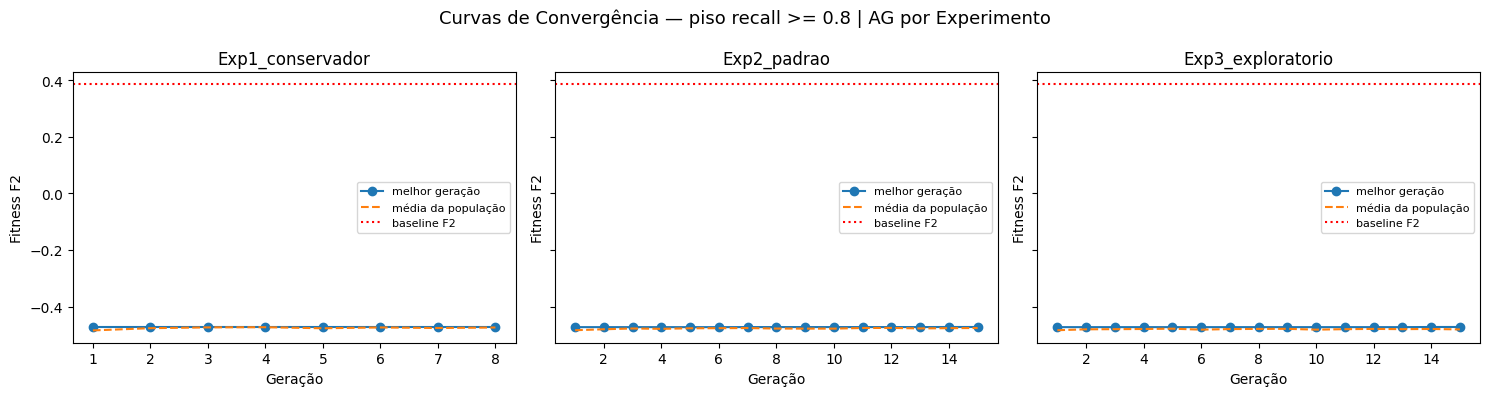

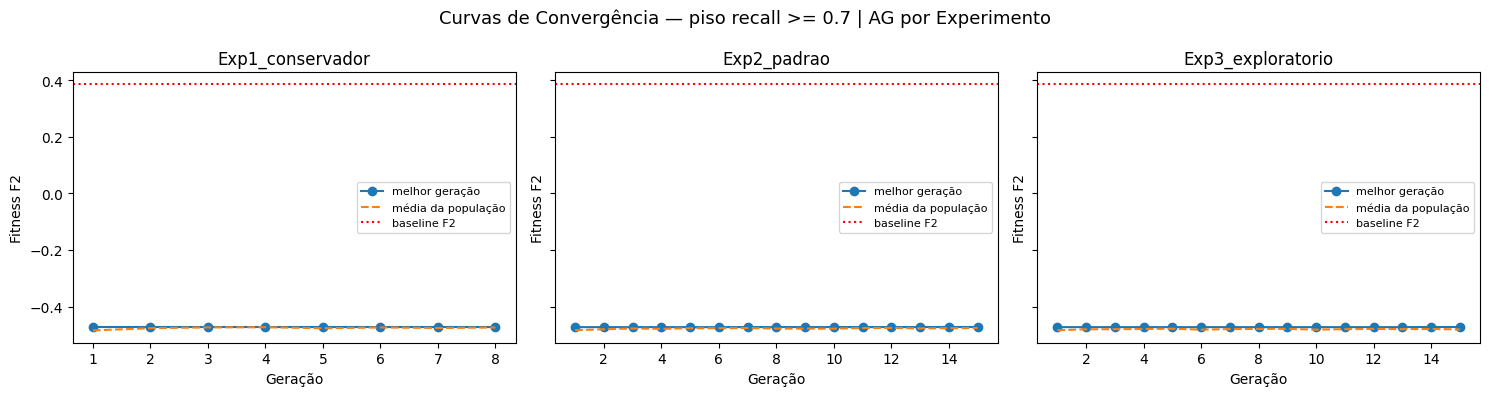

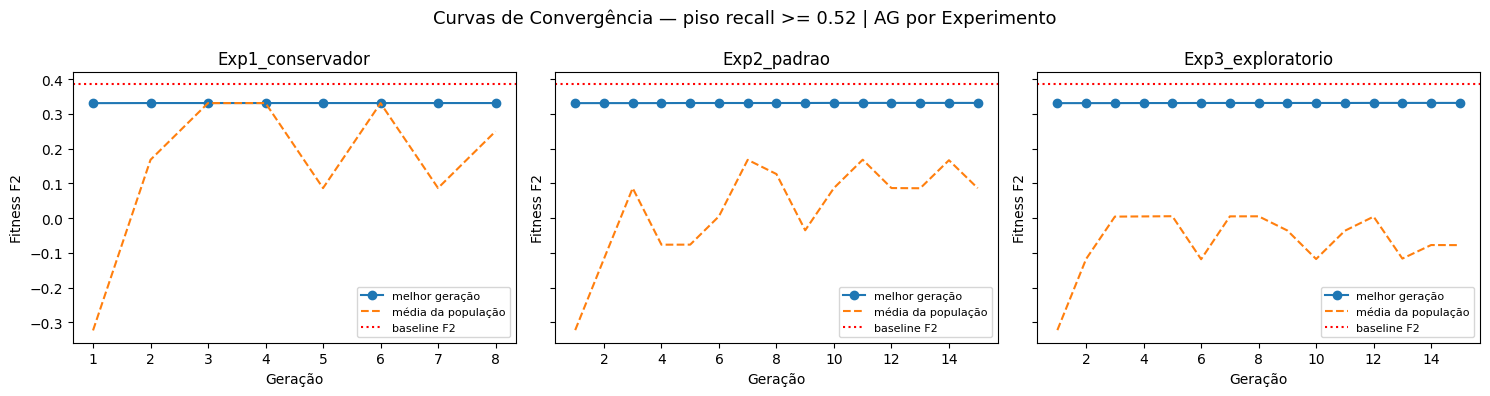

In [32]:
# Curvas de convergência — um painel por cenário de recall
# Fitness negativo → AG preso na penalidade (cenário 0.80)
# Fitness positivo → AG otimizando F2 de verdade (cenário 0.70)

for recall_threshold, experiment_results in scenario_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, (label, result) in zip(axes, experiment_results.items()):
        history = result["history"]

        ax.plot(history["generation"], history["best_fitness"], marker="o", label="melhor geração")
        ax.plot(history["generation"], history["mean_fitness"], linestyle="--", label="média da população")

        ax.axhline(
            baseline_metrics_operational["f2"],
            color="red", linestyle=":", linewidth=1.5, label="baseline F2",
        )

        ax.set_title(label)
        ax.set_xlabel("Geração")
        ax.set_ylabel("Fitness F2")
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Curvas de Convergência — piso recall >= {recall_threshold} | AG por Experimento",
        fontsize=13,
    )
    plt.tight_layout()
    filename = f"01_ag_convergence_recall{str(recall_threshold).replace('.', '')}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=150)
    plt.show()

## Comparativo final: baseline vs experimentos × três cenários de recall

Os melhores parâmetros de cada experimento são usados para treinar um HistGB
no **treino completo** e avaliados no **teste** com threshold operacional (0.40).
Métrica de ordenação: **F2** — consistente com a Fase 1.

**O que esperar de cada cenário:**
- **0.80**: fitness sempre negativo → AG nunca otimizou F2 → resultados próximos ou piores
  que o baseline. Documenta experimentalmente o limite do threshold 0.5.
- **0.70**: zona de transição → alguns experimentos entram em F2, outros não. Convergência
  mais lenta e variável.
- **0.52**: piso derivado dos dados → AG opera em landscape real de F2. Resultado mais
  informativo sobre o potencial real do algoritmo genético neste espaço de hiperparâmetros.

A comparação entre os três cenários é o resultado científico central desta etapa.

In [33]:
def build_comparison_row(label: str, params: dict, cv_fitness: float) -> dict:
    # Treina com os melhores parâmetros e avalia no teste com threshold operacional
    metrics = evaluate_model_on_test(params, threshold=OPERATIONAL_THRESHOLD)
    return {
        "origem": label,
        "params": str(params),
        "cv_fitness": round(cv_fitness, 4),
        **{m: metrics[m] for m in METRIC_NAMES},
    }

In [34]:
scenario_comparison_dfs: dict = {}  # {recall_threshold: DataFrame}

for recall_threshold, experiment_results in scenario_results.items():
    comparison_rows = [
        build_comparison_row(
            label="Baseline (RandomizedSearch Fase 1)",
            params=BASELINE_PARAMS,
            cv_fitness=fitness(_baseline_individual, recall_threshold),
        ),
        *[
            build_comparison_row(
                label=label,
                params=result["best_params"],
                cv_fitness=result["best_cv_fitness"],
            )
            for label, result in experiment_results.items()
        ]
    ]

    df = pd.DataFrame(comparison_rows).set_index("origem")
    scenario_comparison_dfs[recall_threshold] = df

    print(f"\n=== Cenário: recall >= {recall_threshold} no CV ===")
    display(df.round(4))

    filename = f"01_ag_comparison_recall{str(recall_threshold).replace('.', '')}.csv"
    df.to_csv(METRICS_DIR / filename)
    print(f"Salvo: {METRICS_DIR / filename}")

gc.collect()


=== Cenário: recall >= 0.8 no CV ===


,params,cv_fitness,recall,f2,precision,roc_auc,average_precision,brier
origem,,,,,,,,
Baseline (RandomizedSearch Fase 1),"{'min_samples_leaf': 100, 'max_leaf_nodes': 31...",-0.4850,0.9743,0.3857,0.1129,0.5773,0.1507,0.2436
Exp1_conservador,"{'max_iter': 250, 'learning_rate': 0.03, 'max_...",-0.4726,0.9816,0.3854,0.1124,0.5731,0.1470,0.2447
Exp2_padrao,"{'max_iter': 250, 'learning_rate': 0.03, 'max_...",-0.4721,0.9820,0.3853,0.1123,0.5732,0.1466,0.2447
Exp3_exploratorio,"{'max_iter': 250, 'learning_rate': 0.03, 'max_...",-0.4721,0.9820,0.3853,0.1123,0.5732,0.1466,0.2447


Salvo: ../../results/metrics/05_ag_comparison_recall08.csv

=== Cenário: recall >= 0.7 no CV ===


,params,cv_fitness,recall,f2,precision,roc_auc,average_precision,brier
origem,,,,,,,,
Baseline (RandomizedSearch Fase 1),"{'min_samples_leaf': 100, 'max_leaf_nodes': 31...",-0.4850,0.9743,0.3857,0.1129,0.5773,0.1507,0.2436
Exp1_conservador,"{'max_iter': 250, 'learning_rate': 0.03, 'max_...",-0.4726,0.9816,0.3854,0.1124,0.5731,0.1470,0.2447
Exp2_padrao,"{'max_iter': 250, 'learning_rate': 0.03, 'max_...",-0.4721,0.9820,0.3853,0.1123,0.5732,0.1466,0.2447
Exp3_exploratorio,"{'max_iter': 250, 'learning_rate': 0.03, 'max_...",-0.4721,0.9820,0.3853,0.1123,0.5732,0.1466,0.2447


Salvo: ../../results/metrics/05_ag_comparison_recall07.csv

=== Cenário: recall >= 0.52 no CV ===


,params,cv_fitness,recall,f2,precision,roc_auc,average_precision,brier
origem,,,,,,,,
Baseline (RandomizedSearch Fase 1),"{'min_samples_leaf': 100, 'max_leaf_nodes': 31...",-0.4850,0.9743,0.3857,0.1129,0.5773,0.1507,0.2436
Exp1_conservador,"{'max_iter': 350, 'learning_rate': 0.03, 'max_...",0.3313,0.9766,0.3853,0.1126,0.5742,0.1477,0.2443
Exp2_padrao,"{'max_iter': 400, 'learning_rate': 0.1, 'max_l...",0.3317,0.9719,0.3857,0.1130,0.5760,0.1490,0.2436
Exp3_exploratorio,"{'max_iter': 400, 'learning_rate': 0.1, 'max_l...",0.3317,0.9719,0.3857,0.1130,0.5760,0.1490,0.2436


Salvo: ../../results/metrics/05_ag_comparison_recall052.csv


20911

In [35]:
PIVOT_THRESHOLD_FAIL    = 0.01   # melhora mínima de F2 para considerar válida
PIVOT_THRESHOLD_SUCCESS = 0.03   # melhora expressiva de F2
MAX_FP_GROWTH_PCT       = 0.15   # FP pode crescer no máximo 15% vs baseline
MAX_FN_GROWTH_PCT       = 0.30   # FN pode crescer no máximo 30% vs baseline (clínico: FN > FP)
MIN_RECALL_TEST         = 0.80   # piso absoluto de recall no teste (threshold 0.40)

for recall_threshold, comparison_df in scenario_comparison_dfs.items():
    print(f"\n{'='*60}")
    print(f"=== Conclusão — cenário recall >= {recall_threshold} no CV ===")
    print(f"{'='*60}")

    best_experiment = (
        comparison_df
        .drop("Baseline (RandomizedSearch Fase 1)")
        .sort_values("f2", ascending=False)
        .iloc[0]
    )
    baseline_row = comparison_df.loc["Baseline (RandomizedSearch Fase 1)"]

    delta_f2        = best_experiment["f2"]        - baseline_row["f2"]
    delta_recall    = best_experiment["recall"]    - baseline_row["recall"]
    delta_precision = best_experiment["precision"] - baseline_row["precision"]

    print(f"Melhor experimento AG : {best_experiment.name}")
    print(f"F2       : {best_experiment['f2']:.4f}   (baseline: {baseline_row['f2']:.4f}   | delta: {delta_f2:+.4f})")
    print(f"Recall   : {best_experiment['recall']:.4f}   (baseline: {baseline_row['recall']:.4f}   | delta: {delta_recall:+.4f})")
    print(f"Precisão : {best_experiment['precision']:.4f}   (baseline: {baseline_row['precision']:.4f}   | delta: {delta_precision:+.4f})")
    print(f"ROC-AUC  : {best_experiment['roc_auc']:.4f}   (baseline: {baseline_row['roc_auc']:.4f})")

    # ── Estimativa de FN e FP no conjunto de teste ──────────────────────────
    n_prematuros_test = int(y_test.sum())

    fn_baseline = int(n_prematuros_test * (1 - baseline_row["recall"]))
    fn_ag       = int(n_prematuros_test * (1 - best_experiment["recall"]))
    tp_baseline = n_prematuros_test - fn_baseline
    tp_ag       = n_prematuros_test - fn_ag
    fp_baseline = int(tp_baseline / max(baseline_row["precision"], 1e-9) - tp_baseline)
    fp_ag       = int(tp_ag       / max(best_experiment["precision"], 1e-9) - tp_ag)

    fp_growth = (fp_ag - fp_baseline) / max(fp_baseline, 1)
    fn_growth = (fn_ag - fn_baseline) / max(fn_baseline, 1)

    print(f"\nEstimativa no conjunto de teste (threshold={OPERATIONAL_THRESHOLD}):")
    print(f"{'':30} {'Baseline':>10} {'Melhor AG':>10} {'Delta':>10} {'Crescimento':>12}")
    print(f"{'FN (prematuros perdidos)':30} {fn_baseline:>10,} {fn_ag:>10,} {fn_ag - fn_baseline:>+10,} {fn_growth:>+11.1%}")
    print(f"{'FP (alarmes falsos)':30} {fp_baseline:>10,} {fp_ag:>10,} {fp_ag - fp_baseline:>+10,} {fp_growth:>+11.1%}")

    # ── Validação clínica ────────────────────────────────────────────────────
    recall_ok = best_experiment["recall"] >= MIN_RECALL_TEST
    fn_ok     = fn_growth <= MAX_FN_GROWTH_PCT
    fp_ok     = fp_growth <= MAX_FP_GROWTH_PCT

    print("\n--- Validação clínica ---")
    print(f"  Recall >= {MIN_RECALL_TEST} (piso clínico)     : {'✓' if recall_ok else '✗'}  {best_experiment['recall']:.4f}")
    print(f"  FN cresce <= {MAX_FN_GROWTH_PCT:.0%} vs baseline     : {'✓' if fn_ok else '✗'}  crescimento de {fn_growth:+.1%}  ({fn_ag - fn_baseline:+,} prematuros)")
    print(f"  FP cresce <= {MAX_FP_GROWTH_PCT:.0%} vs baseline     : {'✓' if fp_ok else '✗'}  crescimento de {fp_growth:+.1%}  ({fp_ag - fp_baseline:+,} alarmes)")

    if not recall_ok:
        print("  ⚠ Recall abaixo do piso clínico — FN excessivo em termos absolutos")
    if not fn_ok:
        print(f"  ⚠ FN cresceu {fn_growth:+.1%} — prematuros a mais não identificados: {fn_ag - fn_baseline:+,}")
    if not fp_ok:
        print(f"  ⚠ FP cresceu {fp_growth:+.1%} — alarmes falsos em nível inaceitável")

    # ── Critério de pivô ─────────────────────────────────────────────────────
    validacao_ok = recall_ok and fn_ok and fp_ok

    print("\n--- Critério de pivô ---")
    if not validacao_ok:
        print("✗ Falha na validação clínica — não considerar como melhora independente de F2")
        print("  (F2 elevado com FN ou FP fora do limite não representa melhora clínica real)")
    elif delta_f2 >= PIVOT_THRESHOLD_SUCCESS:
        print(f"✓ Melhoria expressiva ({delta_f2:+.4f}) — AG bem-sucedido com FN e FP balanceados.")
        print("  Recomendação: seguir com os parâmetros encontrados pelo AG.")
    elif delta_f2 >= PIVOT_THRESHOLD_FAIL:
        print(f"~ Melhoria marginal ({delta_f2:+.4f}) — combinar com threshold estratificado.")
        print("  Recomendação: aplicar threshold estratificado por perfil de risco.")
    else:
        print(f"✗ Sem melhoria relevante ({delta_f2:+.4f}) — pivotar.")
        print("  Recomendação: revisar piso de recall ou explorar SMOTE/stacking.")


=== Conclusão — cenário recall >= 0.8 no CV ===
Melhor experimento AG : Exp1_conservador
F2       : 0.3854   (baseline: 0.3857   | delta: -0.0003)
Recall   : 0.9816   (baseline: 0.9743   | delta: +0.0073)
Precisão : 0.1124   (baseline: 0.1129   | delta: -0.0005)
ROC-AUC  : 0.5731   (baseline: 0.5773)

Estimativa no conjunto de teste (threshold=0.4):
                                 Baseline  Melhor AG      Delta  Crescimento
FN (prematuros perdidos)              399        285       -114      -28.6%
FP (alarmes falsos)               119,197    120,717     +1,520       +1.3%

--- Validação clínica ---
  Recall >= 0.8 (piso clínico)     : ✓  0.9816
  FN cresce <= 30% vs baseline     : ✓  crescimento de -28.6%  (-114 prematuros)
  FP cresce <= 15% vs baseline     : ✓  crescimento de +1.3%  (+1,520 alarmes)

--- Critério de pivô ---
✗ Sem melhoria relevante (-0.0003) — pivotar.
  Recomendação: revisar piso de recall ou explorar SMOTE/stacking.

=== Conclusão — cenário recall >= 0.7 no CV 